# Image Captioning with BLIP
This notebook demonstrates how to use the BLIP (Bootstrapping Language-Image Pre-training) model from Salesforce to generate both unconditional and conditional captions for uploaded images.

## 1. Setup and Model Loading

In [1]:
!pip install -q transformers torch torchvision pillow
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
from google.colab import files
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model     = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)
print("Model loaded ✓")



Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✓


## 2. Image Upload and Captioning

Saving gettyimages-180680638-676f621f720bc.avif to gettyimages-180680638-676f621f720bc.avif


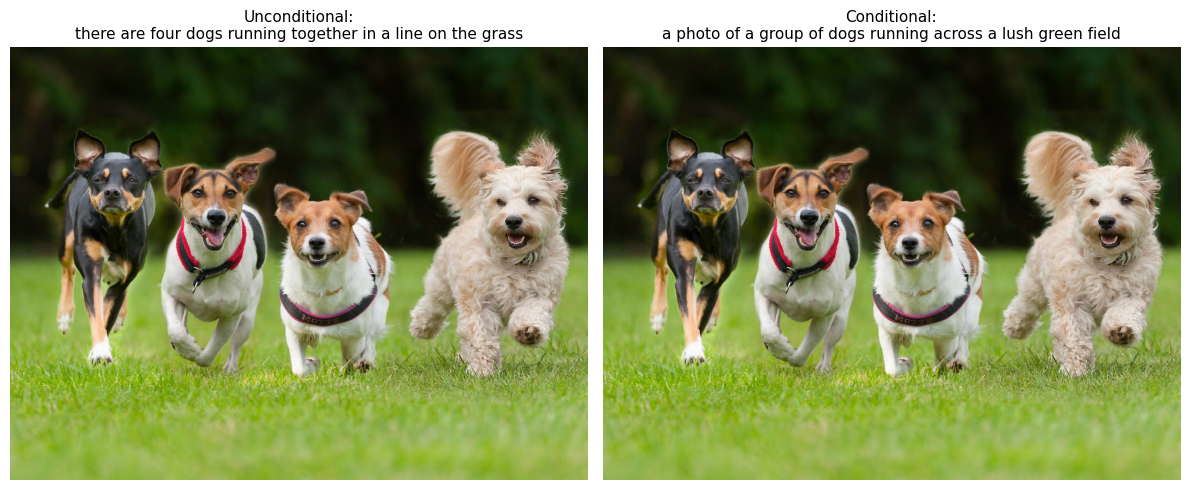

✅ Caption 1: there are four dogs running together in a line on the grass
✅ Caption 2: a photo of a group of dogs running across a lush green field


In [4]:
def caption_image(img_path):
    img     = Image.open(img_path).convert('RGB')
    inputs1 = processor(img, return_tensors='pt').to(device)
    inputs2 = processor(img, text="a photo of", return_tensors='pt').to(device)

    cap1 = processor.decode(model.generate(**inputs1, max_new_tokens=50, num_beams=5)[0], skip_special_tokens=True)
    cap2 = processor.decode(model.generate(**inputs2, max_new_tokens=50, num_beams=5)[0], skip_special_tokens=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (title, cap) in zip(axes, [('Unconditional', cap1), ('Conditional', cap2)]):
        ax.imshow(img)
        ax.set_title(f'{title}:\n{cap}', fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f' Caption 1: {cap1}')
    print(f' Caption 2: {cap2}')

uploaded = files.upload()
caption_image(list(uploaded.keys())[0])